In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import torch.nn as nn 
from torch.utils.data import DataLoader


In [2]:
import torch.optim as optim

In [3]:
%load_ext autoreload
%autoreload 2

In [6]:
torch.cuda.empty_cache()

In [7]:
from torchvision import datasets, transforms

In [8]:
from src import model as ae_model

In [9]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


In [10]:
## transformaciones para el dataset a trabaar
def adjust_mask(x):
    return (x-1).squeeze().long()

target_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(adjust_mask) # Convierte {1,2,3} -> {0,1,2}
])

img_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

In [11]:
pet_data_train = datasets.OxfordIIITPet(root="data", split="trainval", target_types="segmentation" ,download=True, transform=img_transform, target_transform=target_transform)

pet_data_test = datasets.OxfordIIITPet(root="data", split="test", target_types="segmentation" ,download=True, transform=img_transform, target_transform=target_transform)

In [54]:
## dataloader
batch_size = 4 # Ajusta según tu memoria de video (VRAM)

train_loader = DataLoader(
    pet_data_train, 
    batch_size=batch_size, 
    shuffle=True,      
    #num_workers=2,     # Acelera la carga de datos
    #pin_memory=True    # Mejora velocidad de transferencia a GPU
)


test_loader = DataLoader(
    pet_data_test, 
    batch_size=batch_size, 
    shuffle=True,      
    #num_workers=2,     # Acelera la carga de datos
    #pin_memory=True    # Mejora velocidad de transferencia a GPU
)


In [13]:
## parametros para probar entrenamiento autoencoder

params = {
    'in_c': 3,
    # --- ENCODER ---
    'Conv2DParams1': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    'Conv2DParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    
    # Pass-through debe terminar con 128 canales y stride total de 2 para sumar con Conv2DParams2
    'PassThroughParams1': {'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'PassThroughParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    'Conv2DParams3': {'out_c': 256, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.2},

    # --- DECODER ---
    'Conv2DTransposeParams3': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'Conv2DTransposeParams2': {'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # MixParams recibe d2_out (64) + c1_out (64), mantiene 64 canales
    'MixParams': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                  'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # Salida final: 3 canales para las 3 clases del dataset
    'Conv2DTransposeParams1': {'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                               'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0}
}

In [14]:
model = ae_model.AutoEncoderDown3(params).to(device)

In [15]:
model.load_state_dict(torch.load("ae_pesos_base2.pth"))

<All keys matched successfully>

In [30]:
## entrenamiento autoencoder

'''
## losses
criterion = nn.CrossEntropyLoss() # Ideal para las 3 clases del trimapa
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(3):  # Número de épocas
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device) # Debe ser (N, H, W) con valores {0, 1, 2}

        # Forward
        # 'reconstruction' será tu predicción de máscara (N, 3, H, W)
        outputs, _ = model(images) 
        
        loss = criterion(outputs, masks)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    print(f"Época [{epoch+1}/{10}]")
    torch.cuda.empty_cache()

# Guardar pesos del modelo entrenado
torch.save(model.state_dict(), "ae_pesos_base2.pth")


'''

'\n## losses\ncriterion = nn.CrossEntropyLoss() # Ideal para las 3 clases del trimapa\noptimizer = optim.Adam(model.parameters(), lr=1e-4)\n\nfor epoch in range(3):  # Número de épocas\n    for images, masks in train_loader:\n        images = images.to(device)\n        masks = masks.to(device) # Debe ser (N, H, W) con valores {0, 1, 2}\n\n        # Forward\n        # \'reconstruction\' será tu predicción de máscara (N, 3, H, W)\n        outputs, _ = model(images) \n        \n        loss = criterion(outputs, masks)\n        \n        # Backward\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n\n    print(f"Época [{epoch+1}/{10}]")\n    torch.cuda.empty_cache()\n\n# Guardar pesos del modelo entrenado\ntorch.save(model.state_dict(), "ae_pesos_base2.pth")\n\n\n'

Loss en el batch de prueba: 0.7186


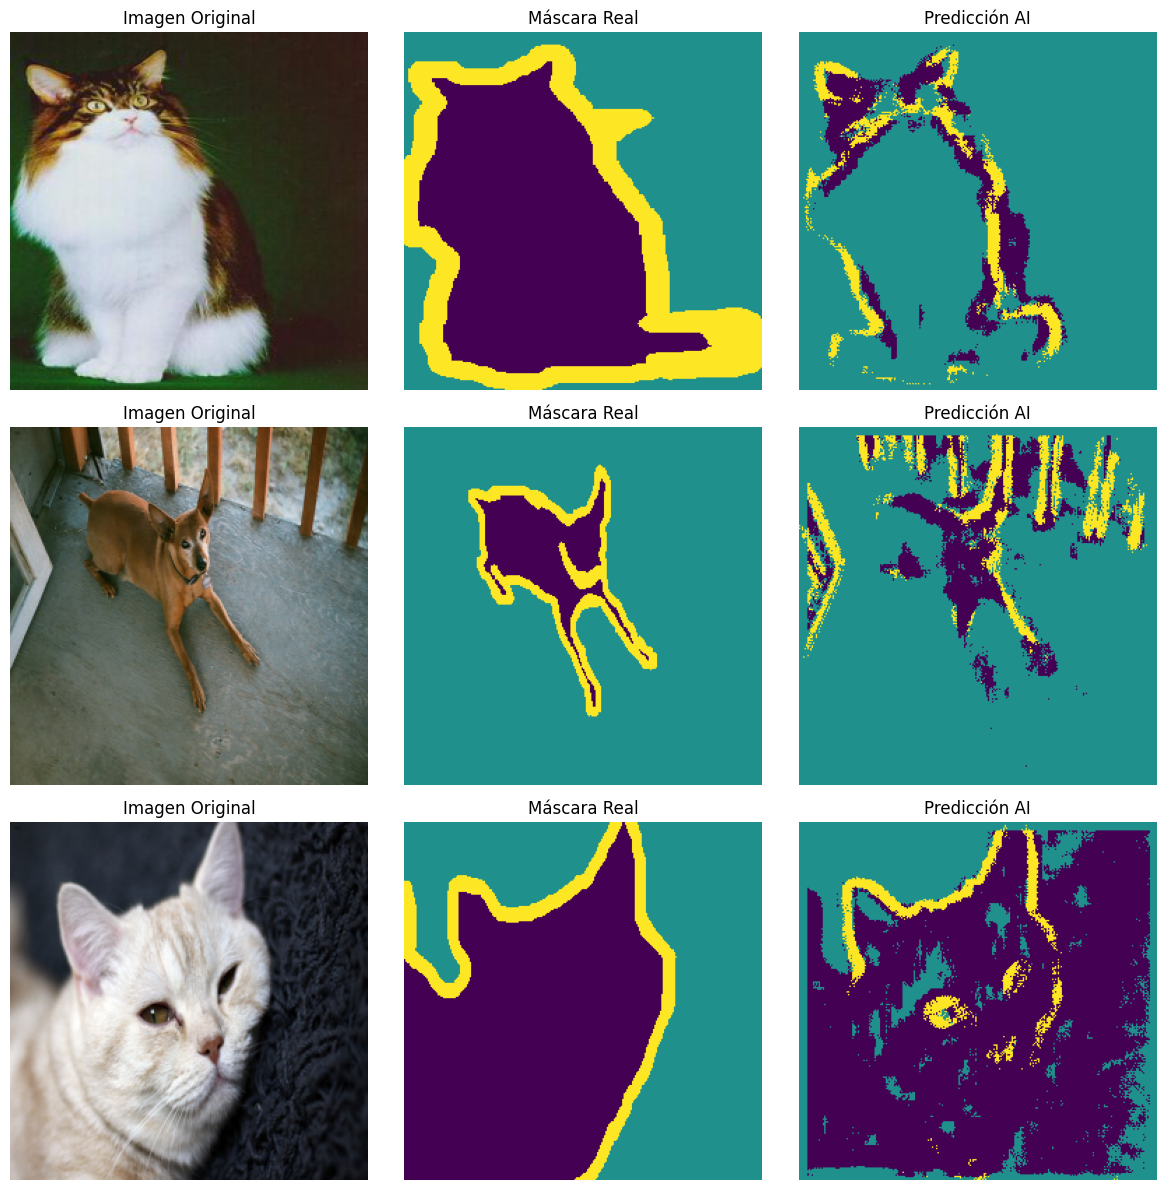

In [27]:
import torch
import matplotlib.pyplot as plt

def probar_modelo(model, test_loader, device, num_images=3):
    model.eval()
    images, masks = next(iter(test_loader)) # Tomamos un batch del test_loader

    criterion = nn.CrossEntropyLoss() 
    
    # Movemos al device
    images = images.to(device)
    masks = masks.to(device)
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes (ahorra memoria)
        # Tu modelo devuelve (reconstruction, latent)
        logits, _ = model(images)
        
        # Los logits tienen forma (Batch, 3, H, W). 
        # Aplicamos argmax en la dimensión de canales (1) para obtener la clase [0, 1, 2]
        preds = torch.argmax(logits, dim=1)

        loss = criterion(logits, masks).item()
        print(f"Loss en el batch de prueba: {loss:.4f}")

    # Visualización
    fig, axes = plt.subplots(num_images, 3, figsize=(12, num_images * 4))
    
    for i in range(num_images):
        # 1. Imagen Original (revertir normalización si la usaste)
        img_vis = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title("Imagen Original")
        axes[i, 0].axis("off")
        
        # 2. Máscara Real (Ground Truth)
        axes[i, 1].imshow(masks[i].cpu().numpy(), cmap='viridis')
        axes[i, 1].set_title("Máscara Real")
        axes[i, 1].axis("off")
        
        # 3. Predicción del Modelo
        axes[i, 2].imshow(preds[i].cpu().numpy(), cmap='viridis')
        axes[i, 2].set_title("Predicción AI")
        axes[i, 2].axis("off")


    plt.tight_layout()
    plt.show()

# Ejecutar la prueba
probar_modelo(model, test_loader, device)

In [24]:
import torch
import matplotlib.pyplot as plt

def comparar_modelos(model1, model2, test_loader, device, num_images=3):
    # 1. Definir el criterio de pérdida (debe ser el mismo usado en el entrenamiento)
    criterion = nn.CrossEntropyLoss()
    
    model1.eval()
    model2.eval()
    
    # Tomamos un batch del test_loader
    images, masks = next(iter(test_loader)) 
    
    # Movemos al device
    images = images.to(device)
    masks = masks.to(device)
    
    with torch.no_grad(): 
        # Inferencia de ambos modelos
        # Recordar que ambos devuelven (reconstruction, latent)
        logits1, _ = model1(images)
        logits2, _ = model2(images)

        # 2. Calcular la pérdida específica de este batch para cada modelo
        loss1 = criterion(logits1, masks).item()
        loss2 = criterion(logits2, masks).item()

        # Obtener las clases [0, 1, 2] con argmax
        preds1 = torch.argmax(logits1, dim=1)
        preds2 = torch.argmax(logits2, dim=1)

    # Visualización
    fig, axes = plt.subplots(num_images, 4, figsize=(18, num_images * 4))
    
    # Añadimos un título general con las pérdidas promedio del batch
    fig.suptitle(f'Comparación de Desempeño\nLoss AE Base: {loss1:.4f} | Loss con NCA: {loss2:.4f}', 
                 fontsize=16, fontweight='bold')

    for i in range(num_images):
        # 1. Imagen Original
        img_vis = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title("Imagen Original")
        axes[i, 0].axis("off")
        
        # 2. Máscara Real (Ground Truth)
        axes[i, 1].imshow(masks[i].cpu().numpy(), cmap='viridis')
        axes[i, 1].set_title("Máscara Real")
        axes[i, 1].axis("off")
        
        # 3. Predicción Encoder-Decoder
        axes[i, 2].imshow(preds1[i].cpu().numpy(), cmap='viridis')
        axes[i, 2].set_title(f"AE Base")
        axes[i, 2].axis("off")

        # 4. Predicción con NCA 
        axes[i, 3].imshow(preds2[i].cpu().numpy(), cmap='viridis')
        axes[i, 3].set_title(f"AE + NCA")
        axes[i, 3].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no se solape el suptitle
    plt.show()

In [46]:
## instaciamos el modelo
nca_entero = ae_model.MetaNCASegmenter(ae_params=params, nca_steps=8).to(device)

In [47]:
# Cargar los pesos   
nca_entero.ae.load_state_dict(torch.load("ae_pesos_base2.pth"))
print("Pesos del Autoencoder cargados correctamente.")

Pesos del Autoencoder cargados correctamente.


In [48]:
ae_test = ae_model.AutoEncoderDown3(params).to(device)
ae_test.load_state_dict(torch.load("ae_pesos_base2.pth"))
print("Pesos del Autoencoder para comparación cargados correctamente.")

Pesos del Autoencoder para comparación cargados correctamente.


In [ ]:
##ahora probaremos unos pasos de entrenamiento del NCA 

## funcion de referencia para entrenar el modelo entrenado de forma entera
def train_nca(model, train_loader, epochs=1, device='cuda'):
    
    # Solo queremos que aprenda la "regla de actualización" del NCA
    for param in model.ae.parameters():
        param.requires_grad = False
        
    # El optimizador solo ve los parámetros del NCA
    optimizer = optim.Adam(model.nca.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for i, (imgs, masks) in enumerate(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            
            optimizer.zero_grad(set_to_none=True)  # Limpia los gradientes del optimizador
            
            # Forward: Obtenemos la máscara predicha
            outputs, _ = model(imgs)
            
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            
            total_loss += loss.item()

            if i % 100 == 0:  # Imprime cada 100 batches
                torch.cuda.empty_cache()  # Limpia la caché de GPU para evitar OOM
                print(f"van {i} bacthes")
            
        print(f"Época [{epoch+1}/{epochs}] - Loss: {total_loss/len(train_loader):.4f}")


In [53]:
import torch

def reporte_memoria():
    # Memoria actualmente usada por tensores
    allocated = torch.cuda.memory_allocated() / 1024**2 
    # Memoria total reservada por PyTorch (el "caché")
    reserved = torch.cuda.memory_reserved() / 1024**2
    
    print(f"Memoria en Tensores: {allocated:.2f} MB")
    print(f"Memoria Reservada (Caché): {reserved:.2f} MB")
    print(f"Memoria 'Libre' dentro del Caché: {(reserved - allocated):.2f} MB")

reporte_memoria()

Memoria en Tensores: 2703.07 MB
Memoria Reservada (Caché): 4046.00 MB
Memoria 'Libre' dentro del Caché: 1342.93 MB


In [ ]:
## entrenamiento metaNCA segmenter
print(" Congelando parámetros del Autoencoder...")
for param in nca_entero.ae.parameters():
    param.requires_grad = False
    param.grad = None  # Forzamos la eliminación de cualquier gradiente residual de la Fase 1

# Aseguramos que el Predictor y el NCA sí calculen gradientes
for param in nca_entero.param_predictor.parameters():
    param.requires_grad = True
nca_entero.nca.leak_factor.requires_grad = True


# Pasamos única y exclusivamente los parámetros que requieren gradiente
# Esto evita que Adam aplique updates o momentum en los tensores congelados
optimizer = optim.Adam([
    {'params': [p for p in nca_entero.nca.parameters() if p.requires_grad]},
    {'params': [p for p in nca_entero.param_predictor.parameters() if p.requires_grad]}
], lr=1e-3)

criterion = nn.CrossEntropyLoss()
nca_entero.to(device)

nca_entero.train()  # Activa modo entrenamiento general para el predictor
nca_entero.ae.eval() # Fuerza al Autoencoder a mantenerse estático

# Blindaje extra: Reemplazamos temporalmente el método train del AE 
# para que ninguna llamada accidental en el loop altere sus sub-capas
def dezafectar_train(mode=True):
    for module in nca_entero.ae.modules():
        if isinstance(module, (nn.BatchNorm2d, nn.Dropout2d)):
            module.eval()
nca_entero.ae.train = dezafectar_train
dezafectar_train()


total_loss = 0
print(" Iniciando loop de prueba preliminar blindado...")

for i, (imgs, masks) in enumerate(train_loader):
    imgs, masks = imgs.to(device), masks.to(device)
    
    # set_to_none=True elimina los gradientes del optimizador liberando VRAM
    optimizer.zero_grad(set_to_none=True)
    
    # Forward: Obtención de la salida a través del meta-NCA latente
    outputs, _ = nca_entero(imgs)
    
    loss = criterion(outputs, masks)
    loss.backward()
    optimizer.step()
    
    # Restricción matemática de estabilidad del autómata celular
    with torch.no_grad():
        nca_entero.nca.leak_factor.clamp_(1e-3, 1e3)
    
    total_loss += loss.item()

    if (i + 1) % 100 == 0:
        print(f"\n✅ Van {i + 1} batches procesados exitosamente.")
        print(f"📊 Loss promedio actual: {total_loss / (i + 1):.4f}")
        print(f"💧 Leak Factor actual: {nca_entero.nca.leak_factor.item():.4f}")
        

🔒 Congelando parámetros del Autoencoder...
🚀 Iniciando loop de prueba preliminar blindado...

✅ Van 100 batches procesados exitosamente.
📊 Loss promedio actual: 0.6762
💧 Leak Factor actual: 0.0654

✅ Van 200 batches procesados exitosamente.
📊 Loss promedio actual: 0.6663
💧 Leak Factor actual: 0.0629

✅ Van 300 batches procesados exitosamente.
📊 Loss promedio actual: 0.6449
💧 Leak Factor actual: 0.0590

✅ Van 400 batches procesados exitosamente.
📊 Loss promedio actual: 0.6421
💧 Leak Factor actual: 0.0612

✅ Van 500 batches procesados exitosamente.
📊 Loss promedio actual: 0.6445
💧 Leak Factor actual: 0.0636

✅ Van 600 batches procesados exitosamente.
📊 Loss promedio actual: 0.6395
💧 Leak Factor actual: 0.0698

✅ Van 700 batches procesados exitosamente.
📊 Loss promedio actual: 0.6371
💧 Leak Factor actual: 0.0658

✅ Van 800 batches procesados exitosamente.
📊 Loss promedio actual: 0.6315
💧 Leak Factor actual: 0.0628

✅ Van 900 batches procesados exitosamente.
📊 Loss promedio actual: 0.6281


In [55]:
#train_nca(nca_entero, train_loader, epochs=1, device=device)

# lo guardamos al final
torch.save(nca_entero.state_dict(), "meta_nca1.pth")

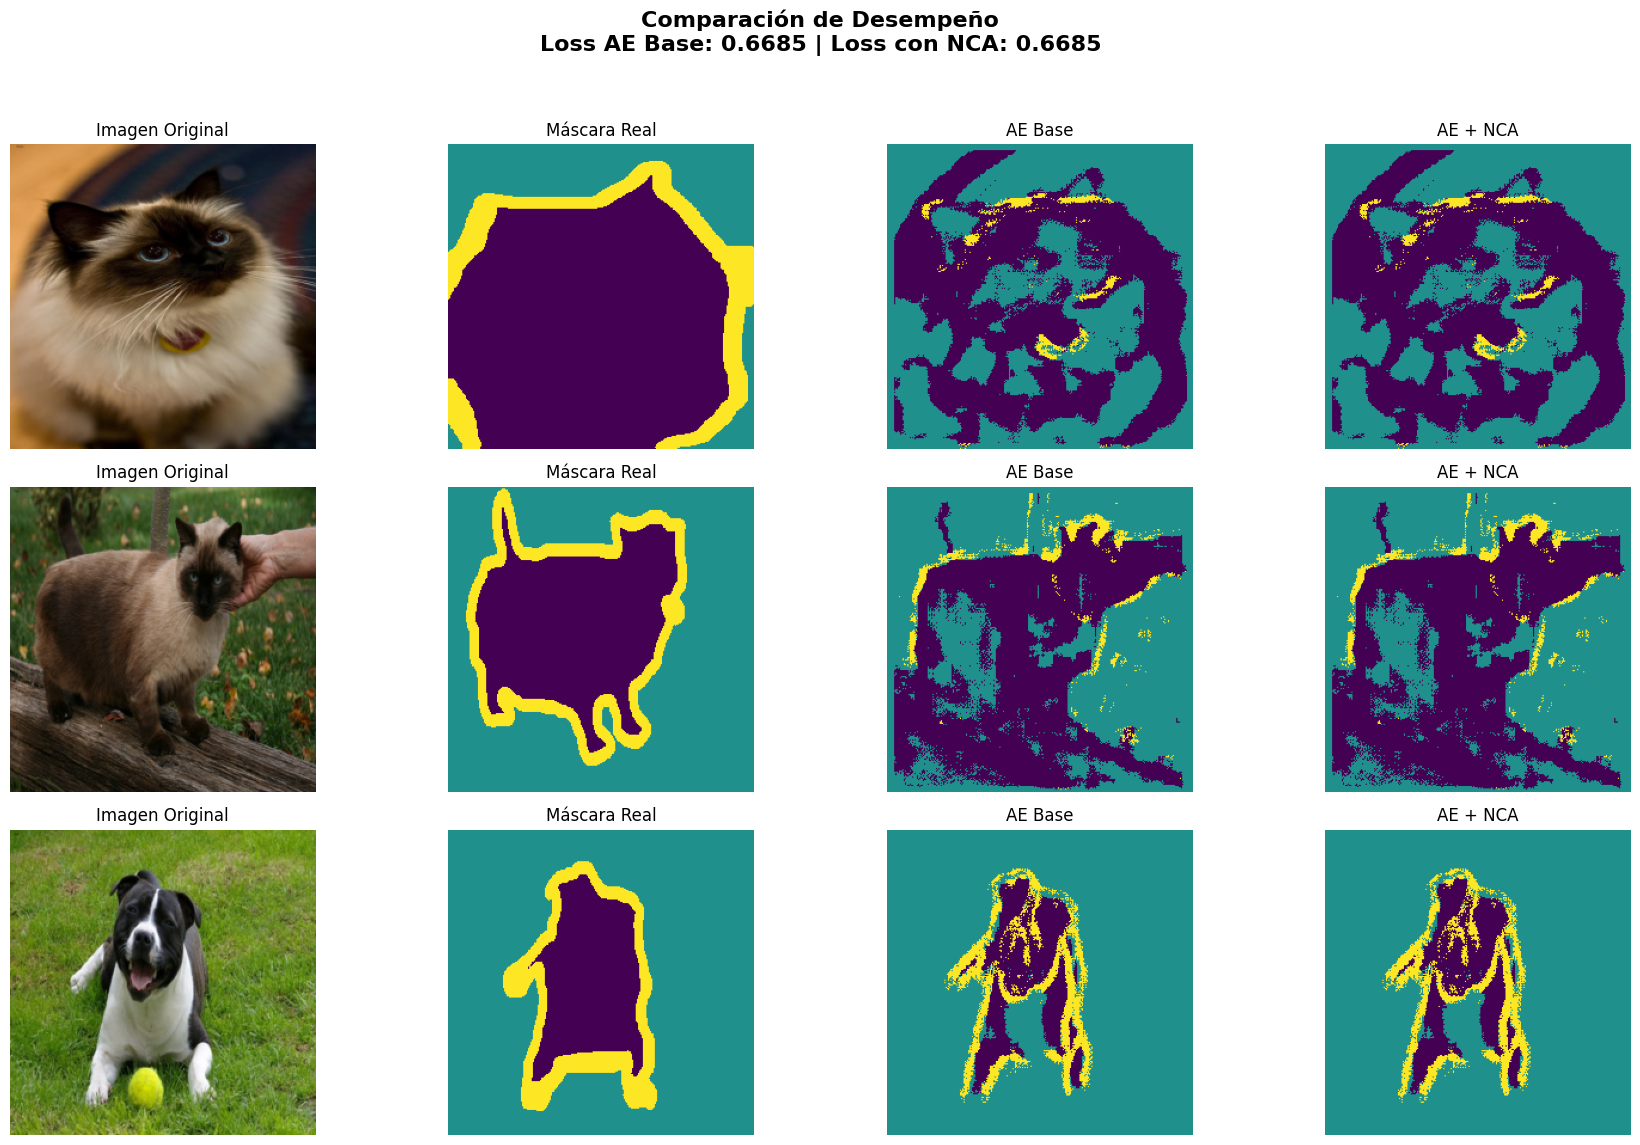

In [57]:
comparar_modelos(nca_entero.ae, ae_test, test_loader, device, num_images=3)